In [ ]:
!pip install scanpy squidpy

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import

In [3]:
import torch

if torch.cuda.is_available():
    device = "cuda"
    print("GPU: ",torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("Using CPU")

Using CPU


In [4]:
##Working with google colab
import os
import sys

os.chdir("/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_m_integrated_1_d")
cwd = os.getcwd()
print(cwd)
sys.path.append("../")

/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_m_integrated_1_d


In [5]:
import scanpy as sc
import squidpy as sq
from anndata import AnnData
import spatialdata as sd
import pandas as pd
from tqdm.notebook import tqdm
import scipy as sp
import numpy as np
import multiprocessing
import pickle as pkl
import torch
import gc
import sklearn.metrics
from sklearn.preprocessing import Normalizer, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

/usr/local/lib/python3.12/dist-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [6]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'DejaVu Sans'

pltkw = dict(bbox_inches='tight', transparent=True)

In [7]:
import importlib
import steamboat_m_integrated_1_d as sf
import steamboat_m_integrated_1_d.tools
import steamboat_m_integrated_1_d.model

In [8]:
importlib.reload(sf)
importlib.reload(sf.tools)
importlib.reload(sf.model)

<module 'steamboat_m_integrated_1_d.model' from '/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_m_integrated_1_d/../steamboat_m_integrated_1_d/model.py'>

## Head weights

In [9]:
adata = sc.read_h5ad("../../Data/Mouse_Coronal_Embeddings/Xenium_Morpho_integrated.h5ad")

Founsation Models

In [9]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Brain/FMs_3/h_optimus.h5ad")
M = edata.obsm['h_optimus']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

In [ ]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Brain/FMs_3/UNI.h5ad")
M = edata.obsm['UNI']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

In [10]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Brain/FMs_3/virchow.h5ad")
M = edata.obsm['virchow']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

In [11]:
edata.obs_names = [cid[61:] for cid in edata.obs['cell_id']]
common_cells = ad.obs_names.intersection(edata.obs_names)
ad.obsm['morpho'][ad.obs_names.get_indexer(common_cells)] = \
  edata.obsm['virchow'][edata.obs_names.get_indexer(common_cells)]

In [12]:
#normalizer = Normalizer(norm="l2")
#ad.obsm['morpho'] = normalizer.transform(ad.obsm['morpho'])

adata.obsm['p_Morpho_Embedding'] = ad.obsm['morpho'] - np.min(ad.obsm['morpho'])

Preparing Dataset

In [13]:
adatas = []
for i in adata.obs['region'].unique():
    adatas.append(adata[adata.obs['region'] == i])
    adatas[-1].obs['global'] = 0  #Only support one unique value for regional observation.

/tmp/ipython-input-4759537.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adatas[-1].obs['global'] = 0  #Only support one unique value for regional observation.


In [14]:
adatas = sf.prep_adatas(adatas, norm=True, log1p=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
sf.set_random_seed(0)
model = sf.model.Steamboat(adatas[0].var_names.tolist(), Morpho_features = adata.obsm['p_Morpho_Embedding'].shape[1], n_heads=50, n_scales=3)
model = model.to(device)
# model.load_state_dict(torch.load('saved_models/mmbrain_new.pth', weights_only=True))

In [ ]:
##working with google colab
model.load_state_dict(torch.load('saved_models/Xmbrain_50_0.3_UNI.pth', weights_only=True), strict=False)

<All keys matched successfully>

In [16]:
##working with laptop
model.load_state_dict(torch.load('saved_models/Xmbrain_50_0.3_virchow.pth', map_location=torch.device('cpu'),weights_only=True))

<All keys matched successfully>

In [ ]:
import gc
gc.collect()

72795

Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.
Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:03<00:00,  3.63s/it]


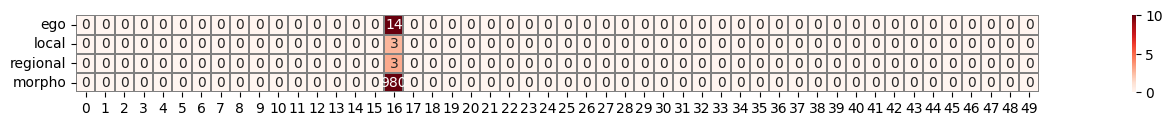

In [17]:
## For simplicity, we only visualize the weights from one slide here, not all of them.
dataset = sf.make_dataset(adatas, regional_obs=['global'])
sf.tools.calc_obs(adatas, dataset, model)
head_weights = sf.tools.calc_head_weights(device, adatas, model)
sf.tools.plot_head_weights(head_weights, figsize=(24, 1), multiplier=1000, heatmap_kwargs={})

In [ ]:
for key in adatas[0].obsm.keys():
  print(key)

Morpho_Embedding
spatial
p_Morpho_Embedding
q_score
k_morpho_score
k_score
k_score_global
attn
ego_attn
morpho_attn
local_attn
regional_attn_0


In [ ]:
l = [0, 13, 33]
for i_head in l: ## Change this to see more
    adatas[0].obs['a_obs'] = adatas[0].obsm['k_score'][:, i_head]
    adatas[0].obs['morpho_obs'] = adatas[0].obsm['k_morpho_score'][:, i_head]
    adatas[0].obs['q_obs'] = adatas[0].obsm['q_score'][:, i_head]
    adatas[0].obs['k_obs'] = adatas[0].obsm['k_score'][:, i_head]

    sq.pl.spatial_scatter(adatas[0],
                          color=['a_obs', 'q_obs', 'k_obs', 'morpho_obs'],
                          shape=None, figsize=(4, 2), size=0.25,
                          legend_fontsize=9, cmap='Reds', ncols=4,
                          colorbar=False, vmin=0., wspace=.0,
                          outline=False, frameon=False,
                          title=['Attention', 'Query', 'Local Key', 'morpgology']
                          )

# Clustering and spatial domain segmentaiton

## virchow

In [ ]:
adatas[0].obsm.keys()

KeysView(AxisArrays with keys: Morpho_Embedding, spatial, p_Morpho_Embedding, q_score, k_morpho_score, k_score, k_score_global, attn, ego_attn, morpho_attn, local_attn, regional_attn_0, local_attn_std)

In [ ]:
!pip install igraph leidenalg

In [ ]:
sf.tools.neighbors(adatas[0], 'attn')  #compute a neighborhood graph on attention embeddings
sf.tools.leiden(adatas[0], resolution=1.)  #clustering cells using the Leiden algorithm

In [ ]:
sq.pl.spatial_scatter(adatas[0], color=['steamboat_clusters'], title=['sc#1_clusters'], shape=None, figsize=(3, 3), ncols=2, legend_loc=None, frameon=False,
                                    size=2., lw=0.,
                      wspace=0.0, hspace=0.0)

In [ ]:
adatas[0].uns.pop('steamboat_clusters_colors', None)

In [19]:
sf.tools.segment(adatas[0], resolution=0.8)

/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_m_integrated_1_d/../steamboat_m_integrated_1_d/tools.py:487: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  return sc.tl.leiden(adata, obsp=key_added_combined + '_connectivities',


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


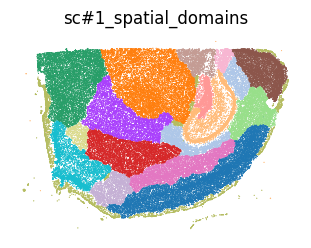

In [20]:
sq.pl.spatial_scatter(adatas[0], color=['steamboat_spatial_domain'],  title=['sc#1_spatial_domains'], shape=None, figsize=(3, 3), ncols=2, legend_loc=None, frameon=False,
                                    size=2., lw=0.,
                      wspace=0.0, hspace=0.0)

In [ ]:
adatas[0].uns.pop('steamboat_spatial_domain_colors', None)

In [ ]:
from sklearn.metrics import silhouette_score

X = adatas[0].obsm['attn']

labels = adatas[0].obs['steamboat_clusters'].astype(str)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

## h_optimus

In [ ]:
adatas[0].obsm.keys()

KeysView(AxisArrays with keys: Morpho_Embedding, spatial, p_Morpho_Embedding, q_score, k_morpho_score, k_score, k_score_global, attn, ego_attn, morpho_attn, local_attn, regional_attn_0, local_attn_std)

In [ ]:
!pip install igraph leidenalg

In [22]:
sf.tools.neighbors(adatas[0], 'attn')  #compute a neighborhood graph on attention embeddings
sf.tools.leiden(adatas[0], resolution=1.)  #clustering cells using the Leiden algorithm

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


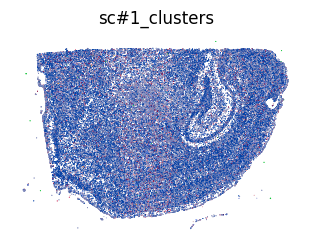

In [23]:
sq.pl.spatial_scatter(adatas[0], color=['steamboat_clusters'], title=['sc#1_clusters'], shape=None, figsize=(3, 3), ncols=2, legend_loc=None, frameon=False,
                                    size=2., lw=0.,
                      wspace=0.0, hspace=0.0)

In [ ]:
adatas[0].uns.pop('steamboat_clusters_colors', None)

In [20]:
sf.tools.segment(adatas[0], resolution=0.8)

/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_m_integrated_1_d/../steamboat_m_integrated_1_d/tools.py:487: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  return sc.tl.leiden(adata, obsp=key_added_combined + '_connectivities',


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


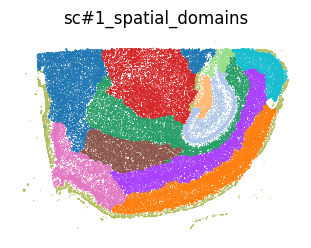

In [21]:
sq.pl.spatial_scatter(adatas[0], color=['steamboat_spatial_domain'],  title=['sc#1_spatial_domains'], shape=None, figsize=(3, 3), ncols=2, legend_loc=None, frameon=False,
                                    size=2., lw=0.,
                      wspace=0.0, hspace=0.0)

In [ ]:
adatas[0].uns.pop('steamboat_spatial_domain_colors', None)

In [ ]:
from sklearn.metrics import silhouette_score

X = adatas[0].obsm['attn']

labels = adatas[0].obs['steamboat_clusters'].astype(str)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.25311252


## UNI

In [ ]:
adatas[0].obsm.keys()

KeysView(AxisArrays with keys: Morpho_Embedding, spatial, p_Morpho_Embedding, q_score, k_morpho_score, k_score, k_score_global, attn, ego_attn, morpho_attn, local_attn, regional_attn_0, local_attn_std)

In [ ]:
!pip install igraph leidenalg

In [33]:
sf.tools.neighbors(adatas[0], 'attn')  #compute a neighborhood graph on attention embeddings
sf.tools.leiden(adatas[0], resolution=1.)  #clustering cells using the Leiden algorithm

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


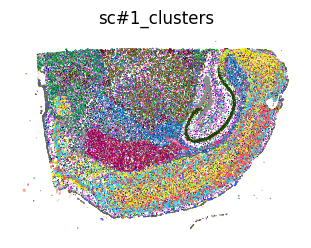

In [34]:
sq.pl.spatial_scatter(adatas[0], color=['steamboat_clusters'], title=['sc#1_clusters'], shape=None, figsize=(3, 3), ncols=2, legend_loc=None, frameon=False,
                                    size=2., lw=0.,
                      wspace=0.0, hspace=0.0)

In [ ]:
adatas[0].uns.pop('steamboat_clusters_colors', None)

In [37]:
sf.tools.segment(adatas[0], resolution=0.8)

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


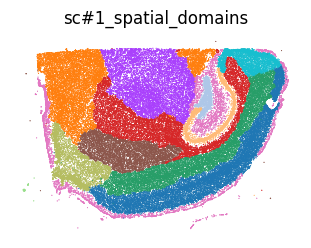

In [38]:
sq.pl.spatial_scatter(adatas[0], color=['steamboat_spatial_domain'],  title=['sc#1_spatial_domains'], shape=None, figsize=(3, 3), ncols=2, legend_loc=None, frameon=False,
                                    size=2., lw=0.,
                      wspace=0.0, hspace=0.0)

In [ ]:
adatas[0].uns.pop('steamboat_spatial_domain_colors', None)

In [39]:
from sklearn.metrics import silhouette_score

X = adatas[0].obsm['attn']

labels = adatas[0].obs['steamboat_clusters'].astype(str)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.25311252
